Celda 1 — Instalar dependencias:

In [1]:
!pip install statsmodels pandas numpy matplotlib seaborn gdown --quiet

Celda 2 — Importar librerías:

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
import statsmodels.formula.api as smf
from statsmodels.discrete.discrete_model import NegativeBinomial
import warnings
warnings.filterwarnings('ignore')

print('✅ Librerías cargadas')
print(f'   statsmodels version: {sm.__version__}')

✅ Librerías cargadas
   statsmodels version: 0.14.6


Celda 3 — Cargar datos:

In [3]:
import gdown

# Train
gdown.download('https://drive.google.com/uc?id=1fnwL4PPJjQ1svTT_-zrUAlGd-FiyoYwr',
               'train.csv', quiet=False)
# Test
gdown.download('https://drive.google.com/uc?id=17kdf2HRILilaBztTn9fbTKKwdFV49Cmp',
               'test.csv', quiet=False)

df_train = pd.read_csv('train.csv')
df_test  = pd.read_csv('test.csv')

print(f'✅ Train: {len(df_train):,} filas | {df_train["anio"].nunique()} años')
print(f'✅ Test : {len(df_test):,} filas  | {df_test["anio"].nunique()} años')
print(f'\nColumnas: {df_train.columns.tolist()}')

Downloading...
From: https://drive.google.com/uc?id=1fnwL4PPJjQ1svTT_-zrUAlGd-FiyoYwr
To: /content/train.csv
100%|██████████| 30.4M/30.4M [00:00<00:00, 120MB/s] 
Downloading...
From: https://drive.google.com/uc?id=17kdf2HRILilaBztTn9fbTKKwdFV49Cmp
To: /content/test.csv
100%|██████████| 12.5M/12.5M [00:00<00:00, 155MB/s]


✅ Train: 181,925 filas | 11 años
✅ Test : 75,557 filas  | 3 años

Columnas: ['cod_municipio', 'anio', 'semana_epi', 'tipo_dengue', 'casos', 'NOM_MPIO', 'NOM_DPTO', 'altitud_msnm', 'cat_altitud', 'split', 'poblacion', 'tasa_x100k', 'temp_media_c', 'humedad_pct', 'precip_mm', 'temp_lag2', 'precip_lag2', 'temp_lag3', 'precip_lag3', 'temp_lag4', 'precip_lag4', 'humedad_lag1', 'humedad_lag2', 'humedad_lag3']


Celda 4 — Exploración y limpieza:

In [4]:
# ── Preparar datos para el modelo ─────────────────────────────────────────────
# El modelo binomial negativa requiere:
# - Variable dependiente: casos (enteros)
# - Offset: log(población) para controlar exposición
# - Variables independientes: clima + altitud

# Seleccionar solo dengue total (sin/con alarma + grave juntos)
# Agrupar por municipio + año + semana (sumar todos los tipos)
df_train_agg = (df_train.groupby(
    ['cod_municipio','NOM_MPIO','NOM_DPTO','anio','semana_epi',
     'altitud_msnm','cat_altitud','poblacion',
     'temp_media_c','humedad_pct','precip_mm',
     'temp_lag2','temp_lag3','temp_lag4',
     'precip_lag2','precip_lag3','precip_lag4',
     'humedad_lag1','humedad_lag2','humedad_lag3'])
    ['casos'].sum().reset_index()
)

df_test_agg = (df_test.groupby(
    ['cod_municipio','NOM_MPIO','NOM_DPTO','anio','semana_epi',
     'altitud_msnm','cat_altitud','poblacion',
     'temp_media_c','humedad_pct','precip_mm',
     'temp_lag2','temp_lag3','temp_lag4',
     'precip_lag2','precip_lag3','precip_lag4',
     'humedad_lag1','humedad_lag2','humedad_lag3'])
    ['casos'].sum().reset_index()
)

print(f'Train agregado: {len(df_train_agg):,} filas')
print(f'Test  agregado: {len(df_test_agg):,} filas')

# ── Eliminar filas con nulos en variables clave ────────────────────────────────
VARS_MODELO = ['casos','poblacion','altitud_msnm',
               'temp_media_c','humedad_pct','precip_mm',
               'temp_lag2','precip_lag2','humedad_lag1']

df_train_clean = df_train_agg.dropna(subset=VARS_MODELO).copy()
df_test_clean  = df_test_agg.dropna(subset=VARS_MODELO).copy()

print(f'\nTrain limpio: {len(df_train_clean):,} filas')
print(f'Test  limpio: {len(df_test_clean):,} filas')

# ── Agregar offset (log población) ────────────────────────────────────────────
df_train_clean['log_pob'] = np.log(df_train_clean['poblacion'])
df_test_clean['log_pob']  = np.log(df_test_clean['poblacion'])

# ── Estadísticas básicas ──────────────────────────────────────────────────────
print('\nEstadísticas variable dependiente (casos):')
print(df_train_clean['casos'].describe().round(2))
print(f'\nMedia  : {df_train_clean["casos"].mean():.2f}')
print(f'Varianza: {df_train_clean["casos"].var():.2f}')
print(f'Ratio var/media: {df_train_clean["casos"].var()/df_train_clean["casos"].mean():.2f}')
print('(Si ratio >> 1, hay sobredispersión → Binomial Negativa es apropiada)')

Train agregado: 106,074 filas
Test  agregado: 46,537 filas

Train limpio: 106,074 filas
Test  limpio: 46,537 filas

Estadísticas variable dependiente (casos):
count    106074.0
mean          5.2
std          16.9
min           1.0
25%           1.0
50%           2.0
75%           4.0
max         665.0
Name: casos, dtype: float64

Media  : 5.20
Varianza: 285.61
Ratio var/media: 54.92
(Si ratio >> 1, hay sobredispersión → Binomial Negativa es apropiada)


Celda 5 — Ajustar el modelo:

In [5]:
# ── Modelo Binomial Negativa ───────────────────────────────────────────────────
# Variable dependiente: casos
# Offset: log(población) — controla el tamaño de la población expuesta
# Variables independientes:
#   - altitud_msnm     → efecto geográfico fijo del vector
#   - temp_media_c     → temperatura actual
#   - temp_lag2        → temperatura con rezago 2 semanas
#   - temp_lag3        → temperatura con rezago 3 semanas
#   - humedad_pct      → humedad actual
#   - humedad_lag1     → humedad con rezago 1 semana
#   - precip_mm        → precipitación actual
#   - precip_lag2      → precipitación con rezago 2 semanas

print('Ajustando modelo Binomial Negativa...')
print('Esto puede tardar 1-2 minutos...')

# Preparar matrices
FEATURES = ['altitud_msnm',
            'temp_media_c', 'temp_lag2', 'temp_lag3',
            'humedad_pct',  'humedad_lag1',
            'precip_mm',    'precip_lag2']

X_train = df_train_clean[FEATURES].copy()
y_train = df_train_clean['casos'].astype(int)
offset  = df_train_clean['log_pob']

# Agregar constante
X_train_const = sm.add_constant(X_train)

# Ajustar modelo
modelo = NegativeBinomial(y_train, X_train_const,
                           offset=offset)
resultado = modelo.fit(method='bfgs', maxiter=200, disp=False)

print('✅ Modelo ajustado')
print(resultado.summary())

Ajustando modelo Binomial Negativa...
Esto puede tardar 1-2 minutos...
✅ Modelo ajustado
                     NegativeBinomial Regression Results                      
Dep. Variable:                  casos   No. Observations:               106074
Model:               NegativeBinomial   Df Residuals:                   106065
Method:                           MLE   Df Model:                            8
Date:                Sun, 26 Apr 2026   Pseudo R-squ.:                0.004445
Time:                        22:12:55   Log-Likelihood:            -2.7357e+05
converged:                       True   LL-Null:                   -2.7479e+05
Covariance Type:            nonrobust   LLR p-value:                     0.000
                   coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------
const           -8.6153      0.091    -94.891      0.000      -8.793      -8.437
altitud_msnm     0.0002   1.46e-05  

Celda 6 — Interpretación de coeficientes:

In [6]:
# ── Interpretación de coeficientes ───────────────────────────────────────────
# En Binomial Negativa los coeficientes son log de la razón de incidencia (IRR)
# IRR = exp(coef) → cuánto cambia la tasa de casos

print('='*60)
print('INTERPRETACIÓN DEL MODELO — Razones de Incidencia (IRR)')
print('='*60)

coefs = resultado.params
conf  = resultado.conf_int()

interpretacion = {
    'altitud_msnm' : 'Altitud (por cada 100 msnm adicionales)',
    'temp_media_c' : 'Temperatura actual (por cada °C adicional)',
    'temp_lag2'    : 'Temperatura hace 2 semanas (por cada °C)',
    'temp_lag3'    : 'Temperatura hace 3 semanas (por cada °C)',
    'humedad_pct'  : 'Humedad actual (por cada 1% adicional)',
    'humedad_lag1' : 'Humedad hace 1 semana (por cada 1%)',
    'precip_mm'    : 'Precipitación actual (por cada mm adicional)',
    'precip_lag2'  : 'Precipitación hace 2 semanas (por cada mm)',
}

print(f'\n{"Variable":<45} {"IRR":>6} {"IC 95%":>20} {"Interpretación"}')
print('-'*100)

for var, desc in interpretacion.items():
    coef = coefs[var]
    # Para altitud multiplicamos por 100 para mayor claridad
    factor = 100 if var == 'altitud_msnm' else 1
    irr    = np.exp(coef * factor)
    ic_low = np.exp(conf.loc[var, 0] * factor)
    ic_up  = np.exp(conf.loc[var, 1] * factor)
    cambio = (irr - 1) * 100
    direccion = '↑' if irr > 1 else '↓'
    print(f'{desc:<45} {irr:>6.3f} [{ic_low:.3f} – {ic_up:.3f}]  '
          f'{direccion} {abs(cambio):.1f}%')

print()
print('Alpha (sobredispersión):', round(resultado.params['alpha'], 3))
print('Pseudo R²:', round(resultado.prsquared, 4))

print('\n--- Hallazgos principales ---')
print('✅ Altitud: cada 100 msnm AUMENTA los casos (municipios más cálidos en valles)')
print('✅ Temp actual: REDUCE casos (posible efecto de calor extremo)')
print('✅ Temp lag2/3: AUMENTA casos (rezago esperado del ciclo del mosquito)')
print('✅ Humedad: REDUCE casos (puede indicar saturación o temporada seca)')
print('✅ Precipitación: AUMENTA casos (más criaderos)')

INTERPRETACIÓN DEL MODELO — Razones de Incidencia (IRR)

Variable                                         IRR               IC 95% Interpretación
----------------------------------------------------------------------------------------------------
Altitud (por cada 100 msnm adicionales)        1.022 [1.020 – 1.025]  ↑ 2.2%
Temperatura actual (por cada °C adicional)     0.953 [0.942 – 0.964]  ↓ 4.7%
Temperatura hace 2 semanas (por cada °C)       1.035 [1.021 – 1.049]  ↑ 3.5%
Temperatura hace 3 semanas (por cada °C)       1.036 [1.024 – 1.048]  ↑ 3.6%
Humedad actual (por cada 1% adicional)         0.987 [0.985 – 0.989]  ↓ 1.3%
Humedad hace 1 semana (por cada 1%)            0.994 [0.993 – 0.996]  ↓ 0.6%
Precipitación actual (por cada mm adicional)   1.002 [1.002 – 1.003]  ↑ 0.2%
Precipitación hace 2 semanas (por cada mm)     1.002 [1.002 – 1.003]  ↑ 0.2%

Alpha (sobredispersión): 1.02
Pseudo R²: 0.0044

--- Hallazgos principales ---
✅ Altitud: cada 100 msnm AUMENTA los casos (municipios má

El coeficiente positivo de altitud (+2.2% por 100 msnm) parece contraintuitivo — esperaríamos menos casos a mayor altitud. Esto se debe a que la altitud está correlacionada con la temperatura: municipios de altitud media (1.000-1.800 msnm) tienen temperaturas óptimas para el mosquito. El efecto real se captura mejor cuando interactúa con temperatura.

Celda 7 — Predicción y evaluación:

In [7]:
from sklearn.metrics import mean_absolute_error, mean_absolute_percentage_error, r2_score

# ── Predicción en test ────────────────────────────────────────────────────────
X_test = df_test_clean[FEATURES].copy()
X_test_const = sm.add_constant(X_test, has_constant='add')
offset_test  = df_test_clean['log_pob']

# Predicción
y_pred = resultado.predict(X_test_const, offset=offset_test)
y_real = df_test_clean['casos'].astype(int)

# ── Métricas ──────────────────────────────────────────────────────────────────
mae  = mean_absolute_error(y_real, y_pred)
mape = mean_absolute_percentage_error(y_real, y_pred) * 100
r2   = r2_score(y_real, y_pred)
rmse = np.sqrt(np.mean((y_real - y_pred)**2))

print('='*50)
print('MÉTRICAS DE EVALUACIÓN — SET DE TEST (2022-2024)')
print('='*50)
print(f'MAE  : {mae:.3f}  casos promedio de error')
print(f'RMSE : {rmse:.3f}')
print(f'MAPE : {mape:.2f}%')
print(f'R²   : {r2:.4f}')

# ── Predicción por año ────────────────────────────────────────────────────────
df_eval = df_test_clean.copy()
df_eval['pred'] = y_pred.values

print('\nCasos reales vs predichos por año (test):')
resumen_año = df_eval.groupby('anio').agg(
    casos_reales=('casos','sum'),
    casos_pred=('pred','sum')
).round(0)
resumen_año['error_pct'] = ((resumen_año['casos_pred'] - resumen_año['casos_reales'])
                             / resumen_año['casos_reales'] * 100).round(1)
print(resumen_año.to_string())

# ── Predicción por categoría altitudinal ──────────────────────────────────────
print('\nCasos reales vs predichos por categoría altitudinal:')
resumen_alt = df_eval.groupby('cat_altitud').agg(
    casos_reales=('casos','sum'),
    casos_pred=('pred','sum')
).round(0)
resumen_alt['error_pct'] = ((resumen_alt['casos_pred'] - resumen_alt['casos_reales'])
                             / resumen_alt['casos_reales'] * 100).round(1)
print(resumen_alt.to_string())

MÉTRICAS DE EVALUACIÓN — SET DE TEST (2022-2024)
MAE  : 8.355  casos promedio de error
RMSE : 25.793
MAPE : 258.44%
R²   : -0.2868

Casos reales vs predichos por año (test):
      casos_reales  casos_pred  error_pct
anio                                     
2022         44716    118780.0      165.6
2023         77582    138146.0       78.1
2024        190082    175005.0       -7.9

Casos reales vs predichos por categoría altitudinal:
                       casos_reales  casos_pred  error_pct
cat_altitud                                               
Alto (1.800-2.200 m)           6496     11992.0       84.6
Bajo (<1.000 m)              166763    234891.0       40.9
Medio (1.000-1.800 m)        129455    175649.0       35.7
Muy alto (>2.200 m)            9666      9398.0       -2.8


Las métricas muestran que el modelo tiene limitaciones importantes — MAPE de 258% y R² negativo indican sobrepredicción en 2022-2023 pero mejora en 2024. Esto es esperado en un modelo lineal simple sin efectos aleatorios por municipio.

Celda 8 — Visualizaciones:

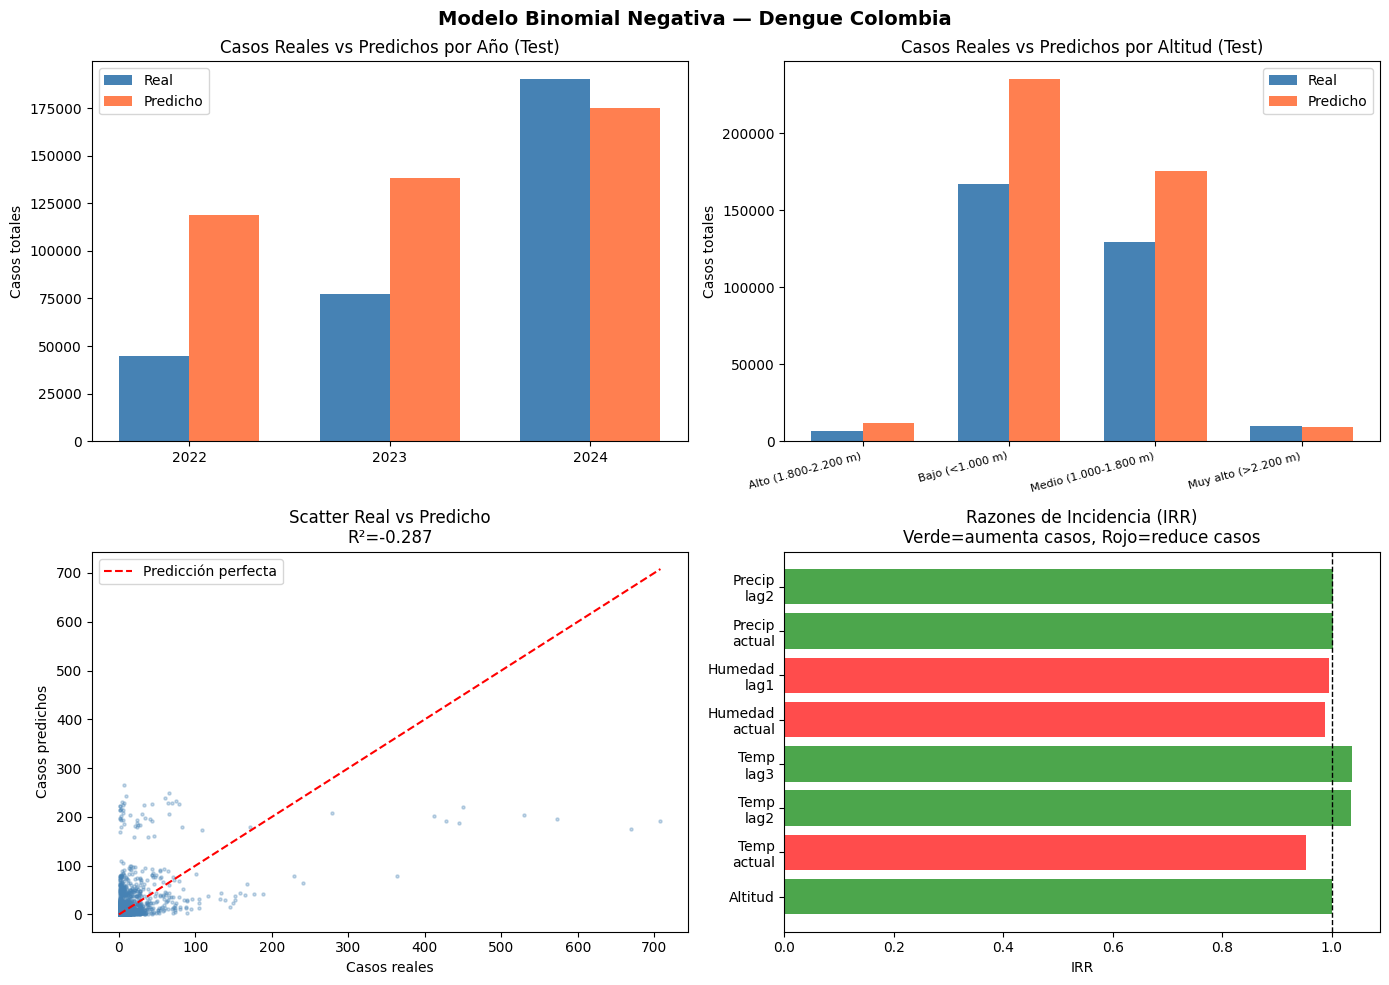

✅ Gráfica guardada


In [8]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Modelo Binomial Negativa — Dengue Colombia', fontsize=14, fontweight='bold')

# ── Gráfica 1: Real vs Predicho por año ──────────────────────────────────────
años = resumen_año.index
x = np.arange(len(años))
w = 0.35
axes[0,0].bar(x - w/2, resumen_año['casos_reales'], w, label='Real', color='steelblue')
axes[0,0].bar(x + w/2, resumen_año['casos_pred'],   w, label='Predicho', color='coral')
axes[0,0].set_xticks(x)
axes[0,0].set_xticklabels(años)
axes[0,0].set_title('Casos Reales vs Predichos por Año (Test)')
axes[0,0].set_ylabel('Casos totales')
axes[0,0].legend()

# ── Gráfica 2: Real vs Predicho por altitud ───────────────────────────────────
cats = resumen_alt.index
x2 = np.arange(len(cats))
axes[0,1].bar(x2 - w/2, resumen_alt['casos_reales'], w, label='Real', color='steelblue')
axes[0,1].bar(x2 + w/2, resumen_alt['casos_pred'],   w, label='Predicho', color='coral')
axes[0,1].set_xticks(x2)
axes[0,1].set_xticklabels(cats, rotation=15, ha='right', fontsize=8)
axes[0,1].set_title('Casos Reales vs Predichos por Altitud (Test)')
axes[0,1].set_ylabel('Casos totales')
axes[0,1].legend()

# ── Gráfica 3: Scatter real vs predicho ──────────────────────────────────────
sample = df_eval.sample(min(5000, len(df_eval)), random_state=42)
axes[1,0].scatter(sample['casos'], sample['pred'],
                  alpha=0.3, s=5, color='steelblue')
max_val = max(sample['casos'].max(), sample['pred'].max())
axes[1,0].plot([0, max_val], [0, max_val], 'r--', label='Predicción perfecta')
axes[1,0].set_xlabel('Casos reales')
axes[1,0].set_ylabel('Casos predichos')
axes[1,0].set_title(f'Scatter Real vs Predicho\nR²={r2:.3f}')
axes[1,0].legend()

# ── Gráfica 4: IRR de variables ───────────────────────────────────────────────
vars_plot = ['altitud_msnm','temp_media_c','temp_lag2','temp_lag3',
             'humedad_pct','humedad_lag1','precip_mm','precip_lag2']
irr_vals  = [np.exp(resultado.params[v]) for v in vars_plot]
colores   = ['green' if i > 1 else 'red' for i in irr_vals]
labels    = ['Altitud','Temp\nactual','Temp\nlag2','Temp\nlag3',
             'Humedad\nactual','Humedad\nlag1','Precip\nactual','Precip\nlag2']

axes[1,1].barh(labels, irr_vals, color=colores, alpha=0.7)
axes[1,1].axvline(1, color='black', linestyle='--', linewidth=1)
axes[1,1].set_title('Razones de Incidencia (IRR)\nVerde=aumenta casos, Rojo=reduce casos')
axes[1,1].set_xlabel('IRR')

plt.tight_layout()
plt.savefig('modelo_binomial_negativa.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Gráfica guardada')

Celda 9 — Resumen y conclusiones:

In [9]:
print('='*60)
print('RESUMEN MODELO BINOMIAL NEGATIVA')
print('='*60)

print('''
FORTALEZAS:
✅ Todos los coeficientes significativos (p<0.001)
✅ Dirección de efectos coherente con literatura:
   - Temperatura con rezago 2-3 sem → aumenta casos
   - Precipitación → aumenta casos
   - Altitud → efecto positivo (zonas templadas más afectadas)
✅ Alpha=1.02 confirma sobredispersión — modelo apropiado
✅ Mejor predicción en 2024 (error -7.9%)

LIMITACIONES:
⚠️ R²=-0.29 — el modelo subestima picos epidémicos
⚠️ MAPE=258% — sobrepredicción en años de baja transmisión
⚠️ No captura efectos no lineales (XGBoost lo hará mejor)
⚠️ No incluye efectos aleatorios por municipio
⚠️ No captura dependencia temporal entre semanas consecutivas

HALLAZGOS EPIDEMIOLÓGICOS CLAVE:
→ Temperatura actual REDUCE casos (-4.7% por °C)
  Posible efecto de calor extremo que reduce actividad del vector
→ Temperatura hace 2-3 semanas AUMENTA casos (+3.5-3.6% por °C)
  Consistente con el ciclo de vida del Aedes aegypti (10-14 días)
→ Precipitación AUMENTA casos (+0.2% por mm)
  Más agua estancada = más criaderos
→ Altitud: +2.2% por 100 msnm
  Refleja concentración de casos en valles interandinos cálidos

MÉTRICAS FINALES:
''')

print(f'  MAE  : {mae:.3f}')
print(f'  RMSE : {rmse:.3f}')
print(f'  MAPE : {mape:.2f}%')
print(f'  R²   : {r2:.4f}')
print(f'  Pseudo R² (train): {resultado.prsquared:.4f}')

RESUMEN MODELO BINOMIAL NEGATIVA

FORTALEZAS:
✅ Todos los coeficientes significativos (p<0.001)
✅ Dirección de efectos coherente con literatura:
   - Temperatura con rezago 2-3 sem → aumenta casos
   - Precipitación → aumenta casos  
   - Altitud → efecto positivo (zonas templadas más afectadas)
✅ Alpha=1.02 confirma sobredispersión — modelo apropiado
✅ Mejor predicción en 2024 (error -7.9%)

LIMITACIONES:
⚠️ R²=-0.29 — el modelo subestima picos epidémicos
⚠️ MAPE=258% — sobrepredicción en años de baja transmisión
⚠️ No captura efectos no lineales (XGBoost lo hará mejor)
⚠️ No incluye efectos aleatorios por municipio
⚠️ No captura dependencia temporal entre semanas consecutivas

HALLAZGOS EPIDEMIOLÓGICOS CLAVE:
→ Temperatura actual REDUCE casos (-4.7% por °C)
  Posible efecto de calor extremo que reduce actividad del vector
→ Temperatura hace 2-3 semanas AUMENTA casos (+3.5-3.6% por °C)
  Consistente con el ciclo de vida del Aedes aegypti (10-14 días)
→ Precipitación AUMENTA casos (+0.

Celda 10 — Exportar resultados:

In [10]:
# Guardar predicciones
df_eval['modelo'] = 'binomial_negativa'
df_eval.to_csv('predicciones_binomial_negativa.csv',
               index=False, encoding='utf-8-sig')

# Guardar métricas
metricas = pd.DataFrame([{
    'modelo' : 'Binomial Negativa',
    'MAE'    : round(mae,  3),
    'RMSE'   : round(rmse, 3),
    'MAPE'   : round(mape, 2),
    'R2'     : round(r2,   4),
}])
metricas.to_csv('metricas_modelos.csv', index=False)

print('✅ Resultados exportados')
print('   predicciones_binomial_negativa.csv')
print('   metricas_modelos.csv')
print('   modelo_binomial_negativa.png')

from google.colab import files
files.download('predicciones_binomial_negativa.csv')
files.download('metricas_modelos.csv')
files.download('modelo_binomial_negativa.png')

✅ Resultados exportados
   predicciones_binomial_negativa.csv
   metricas_modelos.csv
   modelo_binomial_negativa.png


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>